# 1. EDA

El objetivo de este notebook es convertir datos crudos en conocimiento accionable que guíe todas las decisiones posteriores del proyecto.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

## 1.1 CARGA Y PRIMERA VISUALIZACIÓN


El dataset `insurance.csv` se cargará en el DataFrame `df`, que constituye nuestro punto de entrada para el análisis. Este conjunto de datos contiene **1,338 registros** y **7 columnas**, distribuidas en **4 variables numéricas** y **3 variables categóricas**.

### Variables del Dataset

| #   | Variable | Tipo | Descripción |
| --- | --- | --- | --- |
| 1   | **`age`** | Numérica | Edad del beneficiario principal (rango: 18-64 años) |
| 2   | **`sex`** | Categórica | Género del beneficiario: `female` / `male` |
| 3   | **`bmi`** | Numérica | Índice de Masa Corporal (IMC), indicador de obesidad (rango: 15-53) |
| 4   | **`children`** | Numérica | Número de hijos/dependientes cubiertos por el seguro (0-5) |
| 5   | **`smoker`** | Categórica | Hábito tabáquico: `yes` / `no` |
| 6   | **`region`** | Categórica | Región geográfica en Estados Unidos: `southwest`, `southeast`, `northwest`, `northeast` |
| 7   | **`charges`** | Numérica | **Variable Objetivo**: Costos médicos anuales facturados en dólares ($) |



In [30]:
df = pd.read_csv("../data/raw/insurance.csv")
df.sample(10) 

,age,sex,bmi,children,smoker,region,charges
601,51,male,31.635,0,no,northwest,9174.13565
338,50,male,32.300,1,yes,northeast,41919.09700
508,24,female,25.270,0,no,northeast,3044.21330
725,30,female,39.050,3,yes,southeast,40932.42950
8,37,male,29.830,2,no,northeast,6406.41070
1077,21,male,26.030,0,no,northeast,2102.26470
24,37,male,28.025,2,no,northwest,6203.90175
1223,20,female,24.420,0,yes,southeast,26125.67477
89,55,female,26.980,0,no,northwest,11082.57720
975,29,male,22.895,0,yes,northeast,16138.76205


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 1.2. Estadísticas descriptivas

Las variables numéricas no presentan, a primera vista, valores atípicos o inconsistentes. En particular, variables como `age`, `bmi`, `children` y `charges` no contienen valores negativos ni observaciones que resulten evidentemente absurdas, lo que sugiere una buena calidad inicial de los datos.

Por otro lado, las variables categóricas presentan un número reducido de valores únicos, lo cual es consistente con la naturaleza de este tipo de variables. Esto indica que cada una de ellas representa un conjunto de categorías bien definidas y no muestra inconsistencias aparentes en sus etiquetas.


In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [33]:
df.describe(include = [object]).T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


## 1.3. Calidad de los datos (*Data Quality*)

No se encontraron valores nulos en el conjunto de datos. Esta observación fue confirmada tanto mediante la inspección de los datos como con el mapa de calor (*heatmap*), el cual muestra visualmente la ausencia de valores faltantes.

En cuanto a los registros duplicados, únicamente se identificó una observación repetida, correspondiente al índice `581`. Debido a que se trataba de un único registro duplicado, este fue eliminado sin afectar la representatividad del conjunto de datos. Posteriormente, se restableció el índice para mantener una numeración consecutiva y facilitar el análisis posterior.

Respecto a la distribución de las variables categóricas, en general presentan un reparto equilibrado entre sus categorías. La única excepción es la variable `smoker`, en la que existe un desbalance moderado: se registran **1063** personas no fumadoras frente a **274** fumadoras. Aunque esta diferencia es considerable, no representa un desbalance extremo que impida el desarrollo del análisis. En las demás variables categóricas, las frecuencias son relativamente similares entre sus categorías, por lo que no se observan desequilibrios significativos.


In [34]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: >

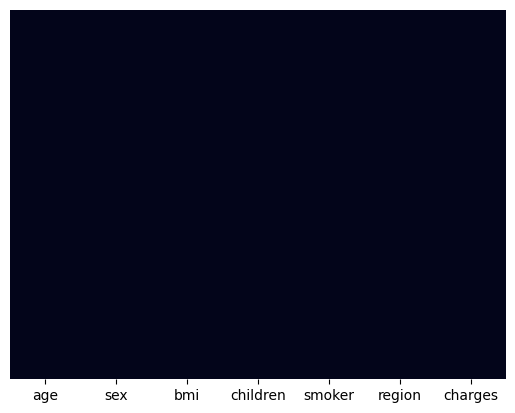

In [35]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

In [36]:
df.duplicated().sum()

np.int64(1)

In [37]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [38]:
df = df.drop_duplicates()

In [39]:
df.reset_index()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...,...
1332,1333,50,male,30.970,3,no,northwest,10600.54830
1333,1334,18,female,31.920,0,no,northeast,2205.98080
1334,1335,18,female,36.850,0,no,southeast,1629.83350
1335,1336,21,female,25.800,0,no,southwest,2007.94500


In [40]:
print(df['sex'].unique())        
print(df['smoker'].unique())    
print(df['region'].unique())     

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [41]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 1.4. ANÁLISIS DE VARIABLES NUMÉRICAS

El análisis de los histogramas muestra que la variable **`age`** no sigue una distribución normal; sin embargo, presenta una distribución prácticamente simétrica, con un **Skewness de 0.055**. Además, su **Kurtosis de -1.244** indica una distribución **platicúrtica**, es decir, más aplanada y con colas menos pronunciadas que una distribución normal.

La variable **`bmi`** presenta una forma mucho más cercana a una distribución normal. Esto se ve respaldado por un **Skewness de 0.284**, que indica una ligera asimetría positiva, y una **Kurtosis de -0.053**, valor muy próximo a cero, lo que sugiere un comportamiento similar al de una distribución normal.

Por su parte, las variables **`children`** y **`charges`** no presentan una distribución normal. La variable **`children`** muestra una **asimetría moderada** (**Skewness = 0.937**) y una **Kurtosis de 0.201**, mientras que **`charges`** exhibe una **fuerte asimetría positiva** (**Skewness = 1.510**) y una **Kurtosis de 1.604**, lo que indica una mayor concentración de valores extremos y colas más pesadas que las de una distribución normal.

Respecto al análisis de valores atípicos mediante el diagrama de caja y el método del **Rango Intercuartílico (IQR)**, las variables **`age`** y **`children`** no presentan observaciones atípicas. En cambio, la variable **`bmi`** contiene **9 valores atípicos**, equivalentes al **0.67 %** del conjunto de datos, mientras que **`charges`** presenta **139 valores atípicos**, que representan aproximadamente el **10.4 %** de las observaciones. Este último resultado es especialmente relevante, ya que evidencia la existencia de un número considerable de costos médicos excepcionalmente altos, los cuales podrían influir significativamente en el ajuste y desempeño de los modelos.


In [42]:
df_numerico = df.select_dtypes(include=["number"])

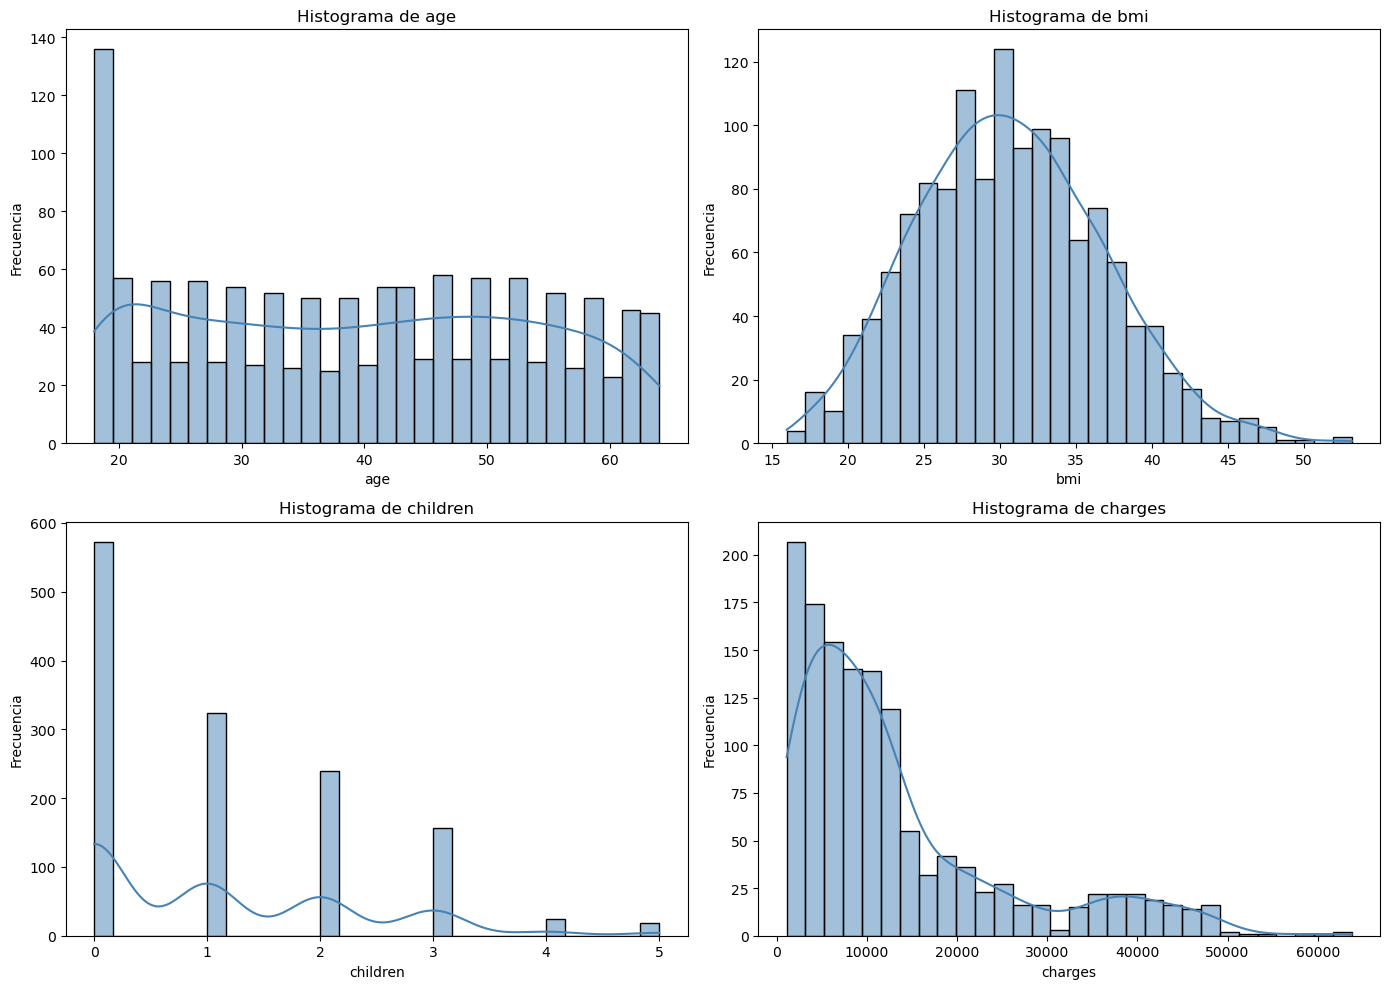

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, col in zip(axes.flatten(), df_numerico.columns):

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color="steelblue",
        edgecolor="black",
        ax=ax
    )

    ax.set_title(f'Histograma de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [44]:
summary = df_numerico.agg(["skew", "kurt"]).T

summary.columns = ["Skewness", "Kurtosis"]

summary = summary.round(3)

summary

,Skewness,Kurtosis
age,0.055,-1.244
bmi,0.284,-0.053
children,0.937,0.201
charges,1.515,1.604


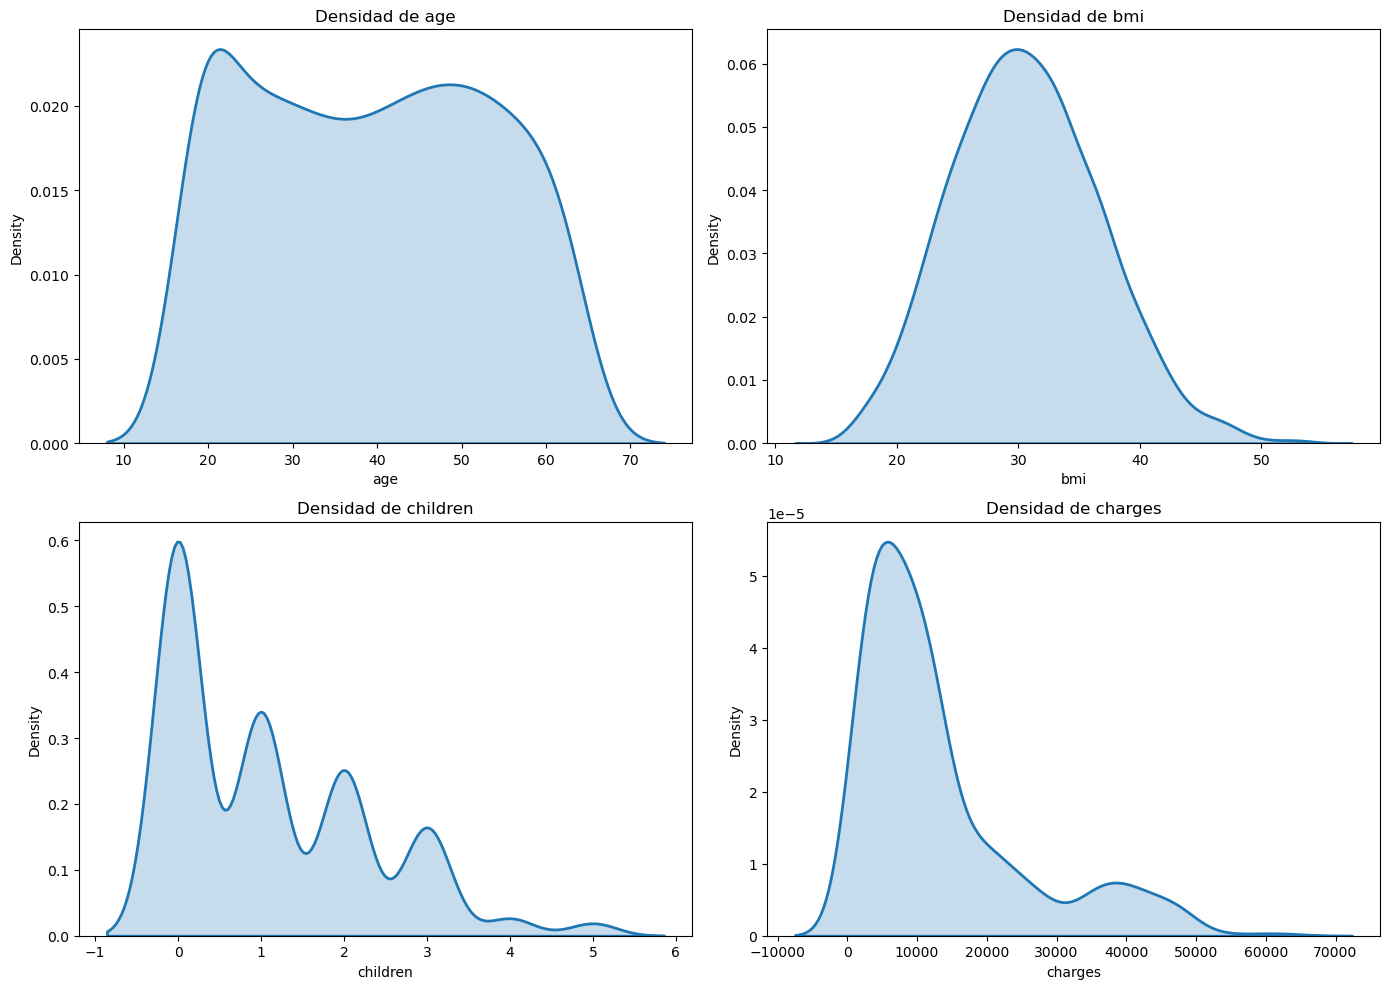

In [45]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, col in zip(axes.flatten(), df_numerico.columns):

    sns.kdeplot(
        data=df,
        x=col,
        fill=True,
        linewidth=2,
        ax=ax
    )

    ax.set_title(f'Densidad de {col}')

plt.tight_layout()
plt.show()

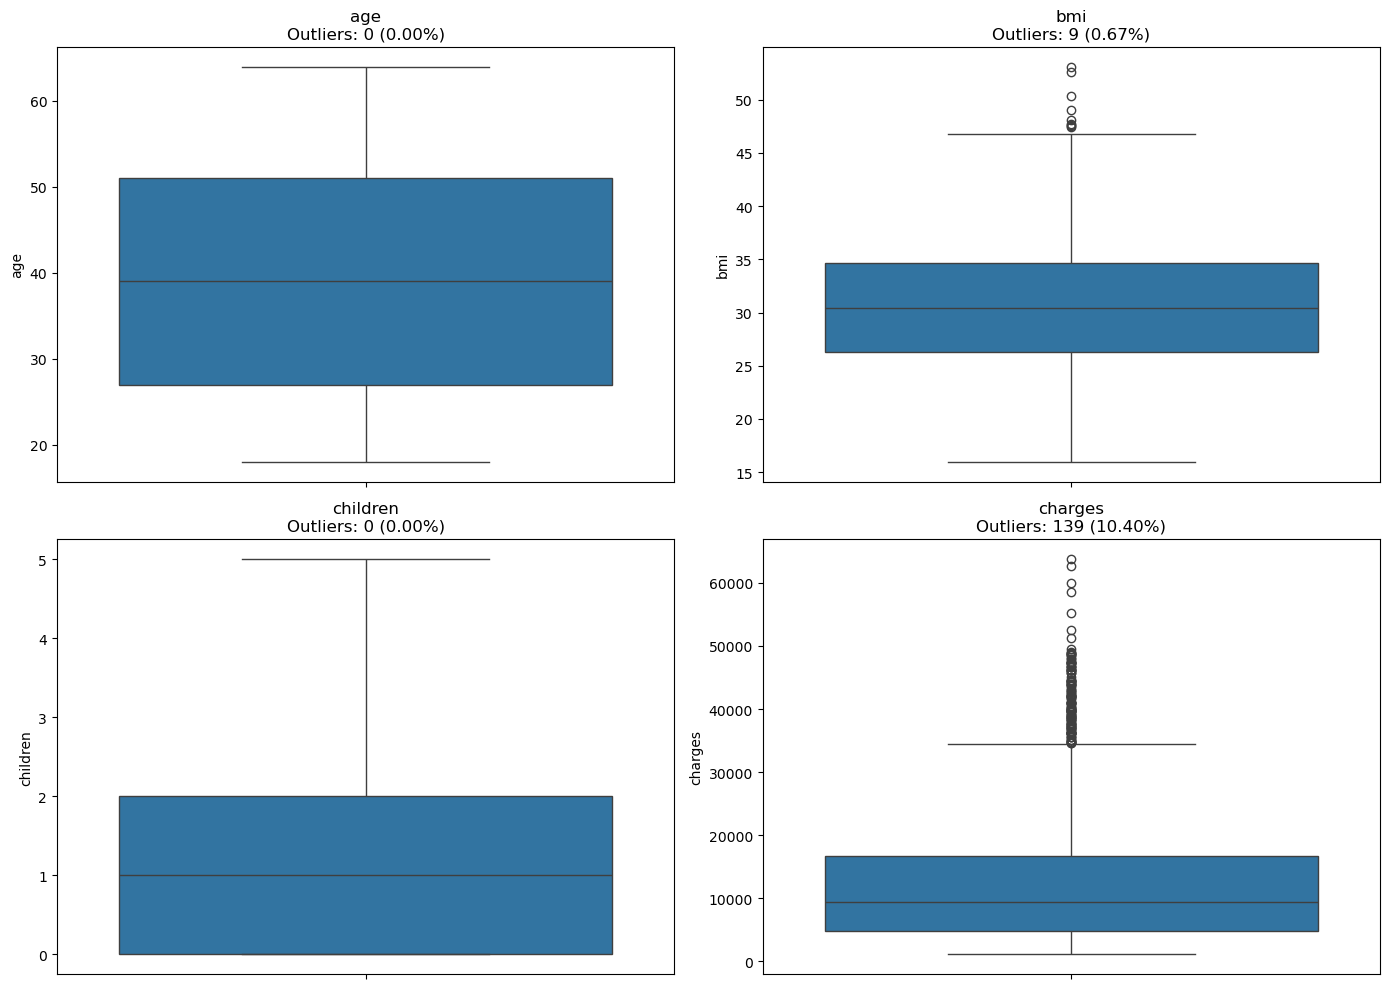

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), df_numerico.columns):

    # Cálculo del IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificación de outliers
    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ]

    sns.boxplot(
        data=df,
        y=col,
        ax=ax
    )

    ax.set_title(
        f'{col}\nOutliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)'
    )

plt.tight_layout()
plt.show()

## 1.5. ANÁLISIS DE VARIABLES CATEGÓRICAS


Se omitirá un análisis aquí. 

In [47]:
df_categorico = df.select_dtypes(include=["object", "category", "bool"])

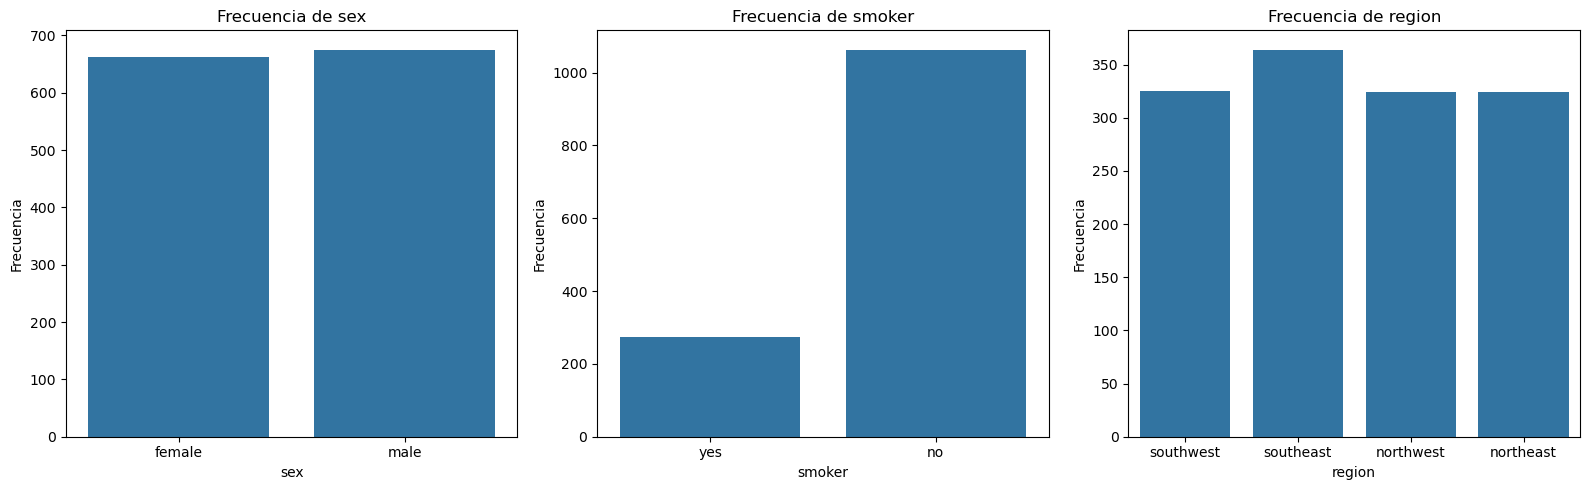

In [48]:
fig, axes = plt.subplots(1, len(df_categorico.columns), figsize=(16, 5))

if len(df_categorico.columns) == 1:
    axes = [axes]

for ax, col in zip(axes, df_categorico.columns):

    sns.countplot(
        data=df,
        x=col,
        ax=ax
    )

    ax.set_title(f'Frecuencia de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 1.6. Relaciones entre variables

Con el objetivo de comprender cómo se relacionan las variables predictoras con la variable objetivo **`charges`**, se realizó un análisis mediante diagramas de dispersión y una matriz de correlación de Pearson.

En el gráfico de dispersión entre **`age`** y **`charges`** se observan varias bandas aproximadamente paralelas, lo que sugiere la existencia de subgrupos dentro de los datos, posiblemente asociados a otras variables como **`smoker`**. Aunque se aprecia una tendencia creciente, la relación lineal es únicamente **moderada**, por lo que la edad explica solo una parte de la variabilidad de los costos médicos.

Para la variable **`bmi`**, el diagrama de dispersión muestra una nube de puntos con forma de abanico o cono, evidenciando una alta dispersión de los datos. A pesar de observarse una ligera tendencia positiva, la relación lineal es débil y existe una considerable variabilidad en los valores de **`charges`** para un mismo índice de masa corporal.

En el caso de **`children`**, al tratarse de una variable discreta, los datos se agrupan en líneas verticales correspondientes a cada número de hijos. No se aprecia una tendencia lineal clara, lo que sugiere que esta variable, por sí sola, aporta poca información para explicar el costo del seguro médico.

La matriz de correlación de Pearson confirma estas observaciones. La variable **`age`** presenta la mayor correlación con **`charges`** (**0.30**), seguida de **`bmi`** (**0.20**), mientras que **`children`** muestra una correlación muy baja (**0.07**). Estos resultados indican que ninguna de las variables numéricas posee una relación lineal fuerte con la variable objetivo de manera individual.

Asimismo, las correlaciones entre las variables predictoras son muy reducidas. La mayor corresponde a **`age`** y **`bmi`**, con un coeficiente aproximado de **0.11**, lo que indica una asociación prácticamente despreciable. En consecuencia, no existe evidencia de una fuerte relación lineal entre las variables numéricas, por lo que no se esperan problemas importantes de multicolinealidad derivados de estas características.


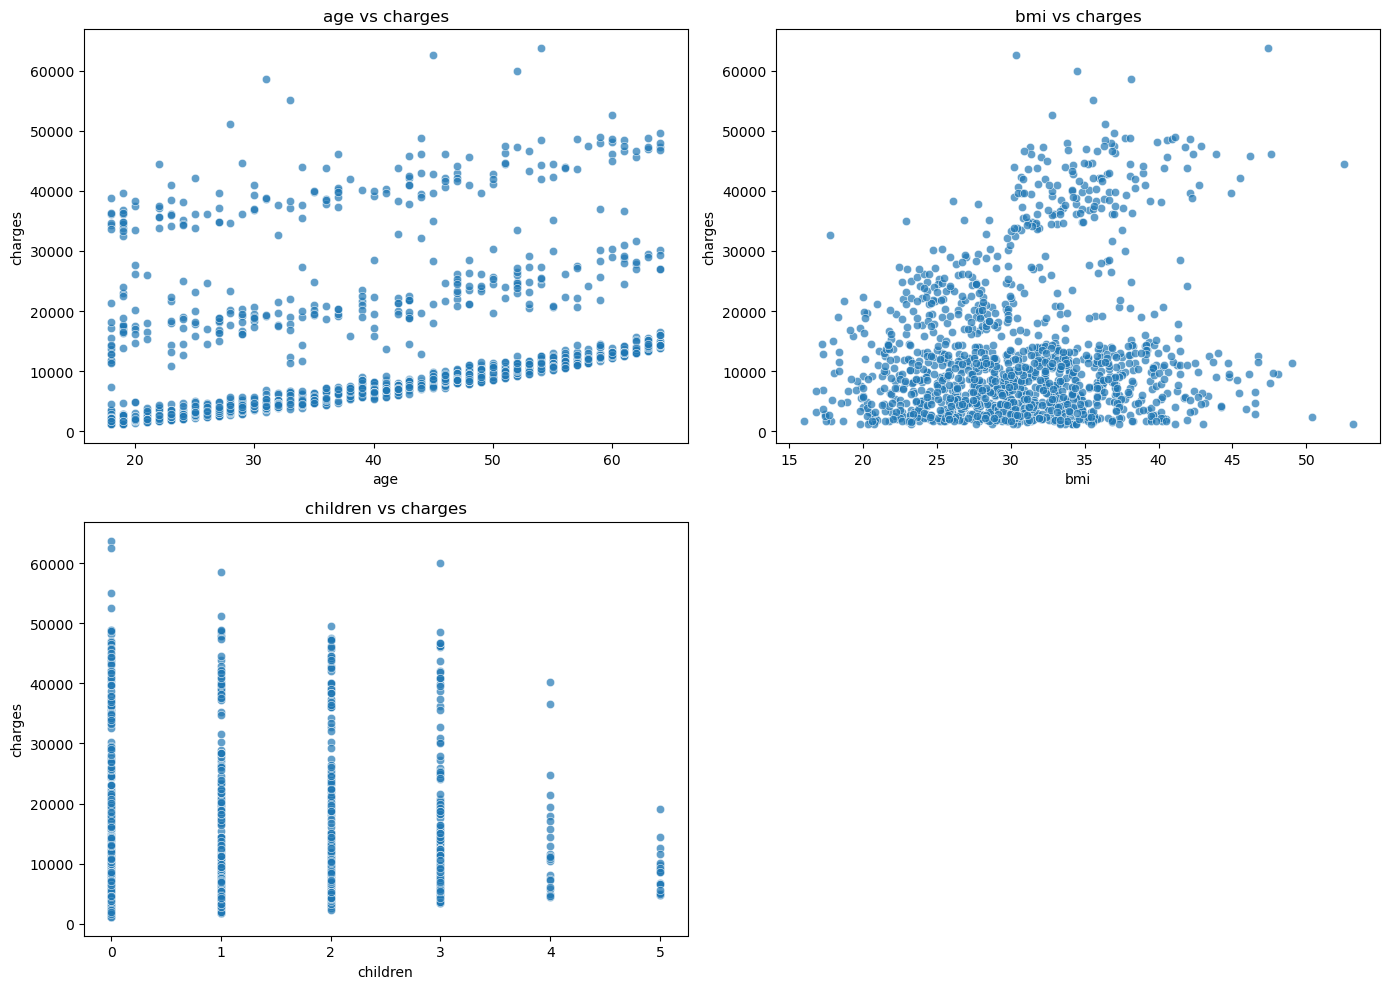

In [49]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

variables = [col for col in df_numerico.columns if col != "charges"]

for ax, col in zip(axes.flatten(), variables):

    sns.scatterplot(
        data=df,
        x=col,
        y="charges",
        alpha=0.7,
        ax=ax
    )

    ax.set_title(f'{col} vs charges')

fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

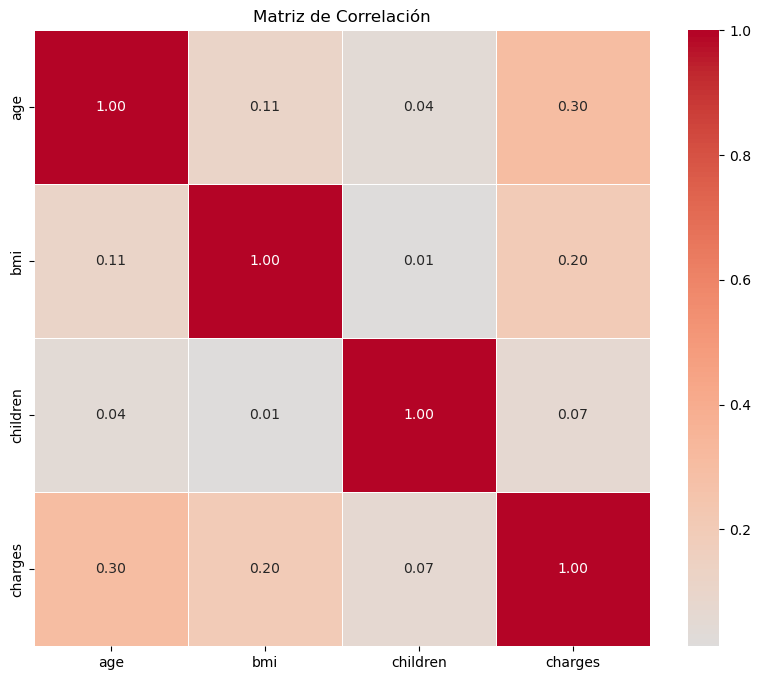

In [50]:
correlation_matrix = df[['age', 'bmi', 'children', 'charges']].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

## 1.7. Análisis de la variable objetivo (`charges`)

La variable **`charges`** presenta una distribución con una marcada asimetría positiva y no cumple el supuesto de normalidad de acuerdo con la prueba de **Shapiro-Wilk** $p < 0.05$. Con el propósito de reducir dicha asimetría, se aplicó una transformación logarítmica mediante $log(1p)$, obteniendo una distribución considerablemente más cercana a la normal. Esta mejora se refleja en el incremento del estadístico de Shapiro-Wilk, que pasó de **0.8148** a **0.9833**.

No obstante, la prueba continúa rechazando la hipótesis nula de normalidad $p < 0.05$. Este resultado es esperable debido al tamaño de la muestra $n = 1337$, ya que la prueba de Shapiro-Wilk es altamente sensible en conjuntos de datos grandes y puede detectar como estadísticamente significativas desviaciones muy pequeñas respecto a la normalidad. Por ello, aunque la transformación mejora notablemente la forma de la distribución, la normalidad estricta no se alcanza según este criterio estadístico.

Adicionalmente, mediante el análisis de los **pairplots**, se observó el comportamiento de las variables numéricas al separarlas por cada variable categórica. La variable **`smoker`** destaca claramente sobre las demás, ya que produce una separación evidente en las distribuciones de **`charges`**: las personas fumadoras presentan, en general, costos médicos considerablemente mayores que las no fumadoras. En contraste, las variables categóricas **`sex`** y **`region`** muestran distribuciones muy similares entre sus categorías, sin diferencias visuales tan marcadas. Esto sugiere que **`smoker`** es la variable categórica con mayor capacidad explicativa respecto a la variabilidad de **`charges`**, mientras que las demás presentan un efecto mucho menos pronunciado.


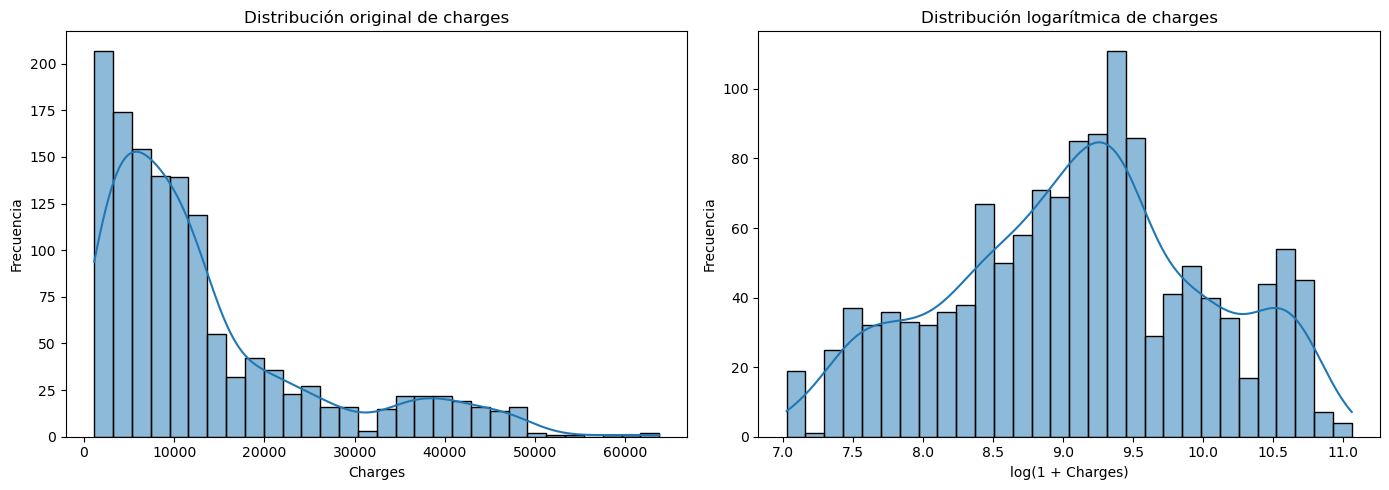

===== Prueba de Shapiro-Wilk =====
Charges originales
 Estadístico: 0.8148
 p-value:     0.000000
 No normal

Charges transformadas (log1p)
 Estadístico: 0.9833
 p-value:     0.000000
 No normal


In [51]:
df["log_charges"] = np.log1p(df["charges"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="charges",
    bins=30,
    kde=True,
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Distribución original de charges")
axes[0].set_xlabel("Charges")
axes[0].set_ylabel("Frecuencia")

sns.histplot(
    data=df,
    x="log_charges",
    bins=30,
    kde=True,
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_title("Distribución logarítmica de charges")
axes[1].set_xlabel("log(1 + Charges)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


stat_original, p_original = shapiro(df["charges"])
stat_log, p_log = shapiro(df["log_charges"])

print("===== Prueba de Shapiro-Wilk =====")
print(f"Charges originales")
print(f" Estadístico: {stat_original:.4f}")
print(f" p-value:     {p_original:.6f}")
print(" Normal" if p_original >= 0.05 else " No normal")

print()

print(f"Charges transformadas (log1p)")
print(f" Estadístico: {stat_log:.4f}")
print(f" p-value:     {p_log:.6f}")
print(" Normal" if p_log >= 0.05 else " No normal")

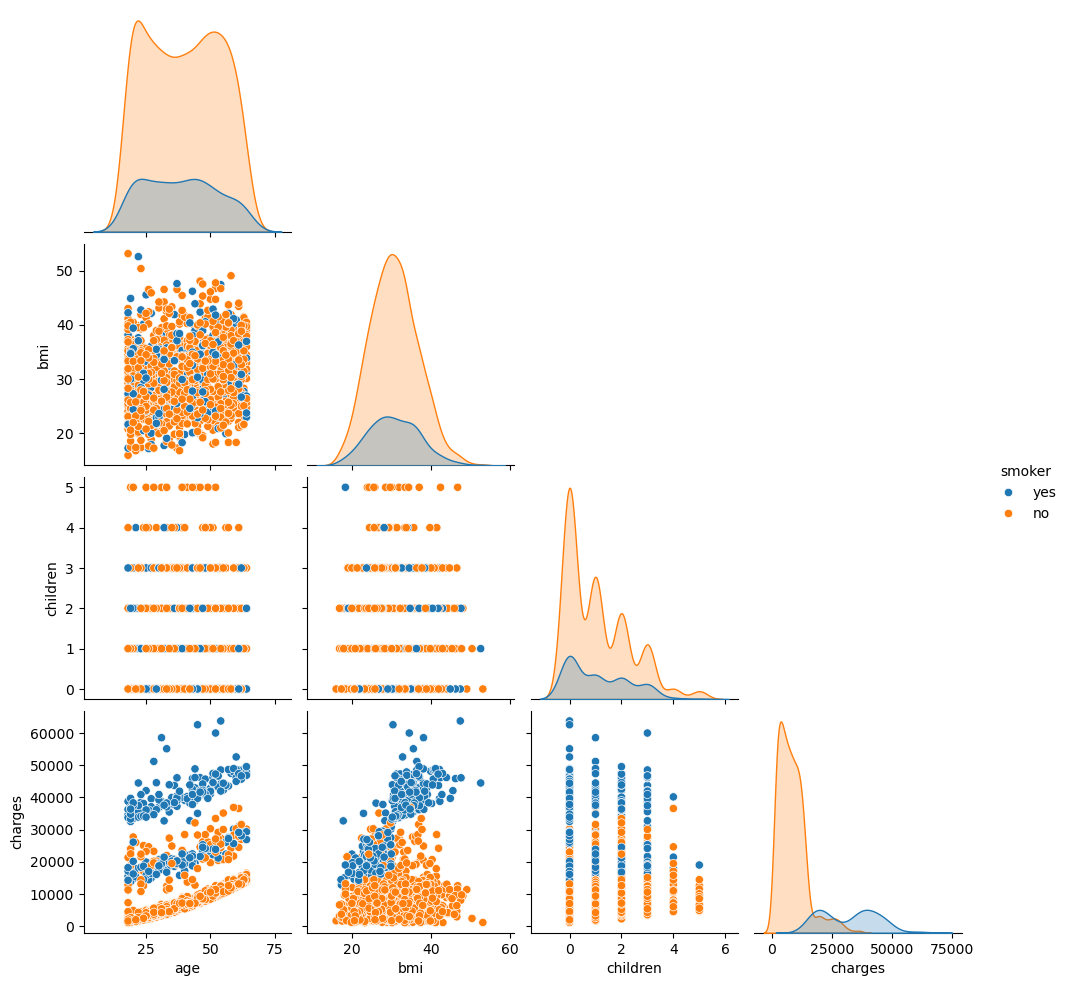

In [52]:
sns.pairplot(df, vars=['age', 'bmi', 'children', 'charges'], 
             hue='smoker', corner=True)
plt.show()

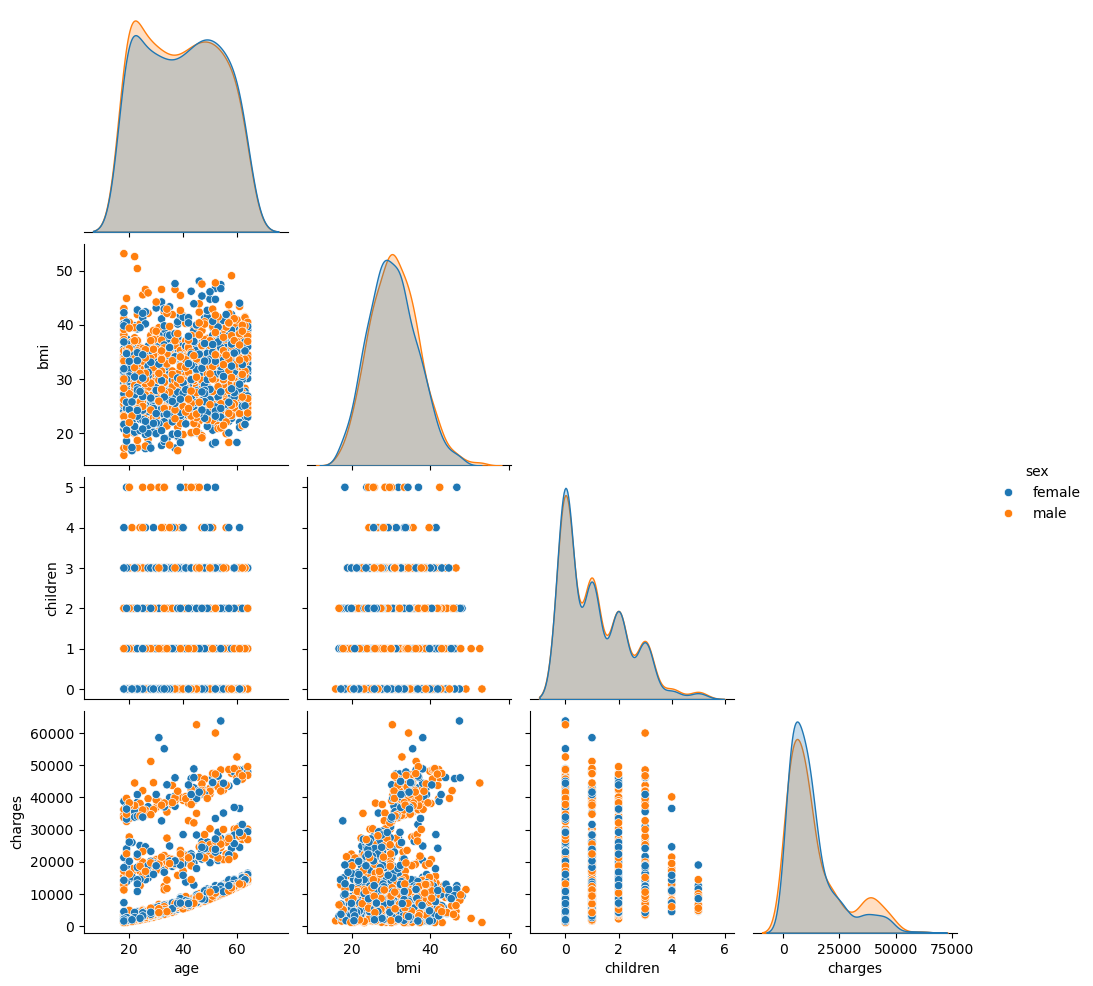

In [53]:
sns.pairplot(df, vars=['age', 'bmi', 'children', 'charges'], 
             hue='sex', corner=True)
plt.show()

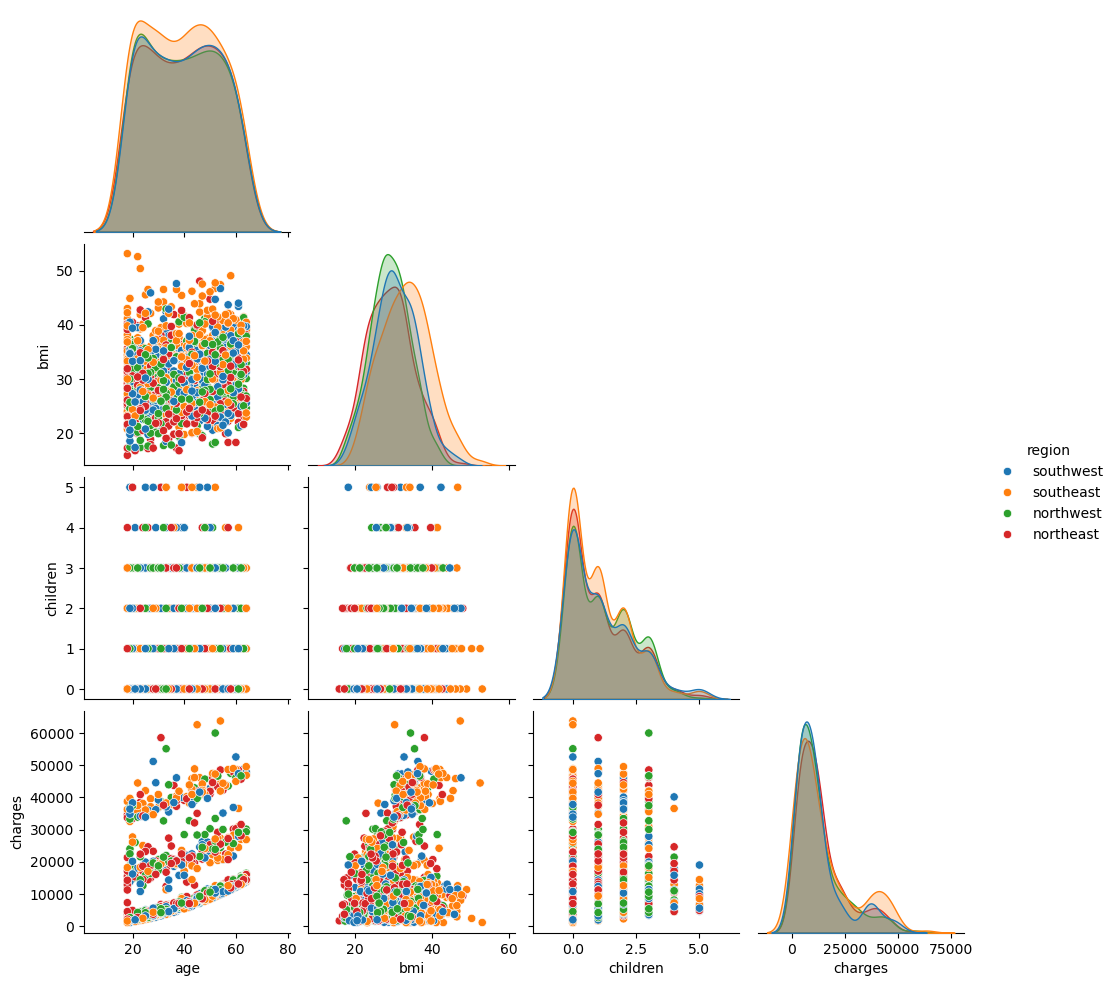

In [54]:
sns.pairplot(df, vars=['age', 'bmi', 'children', 'charges'], 
             hue='region', corner=True)
plt.show()

In [55]:
df.to_csv('../data/processed/01_insurance.csv', index=False)